In [659]:
import numpy as np
import pandas as pd

import fastgoertzel as fg

SAMPLE_RATE = 44100
DATA_AMOUNT = 50e3 # Amount of symbols/bits togenerate transmit
SYMBOL_RATE = 300
SYMBOL_DURATION = SAMPLE_RATE // SYMBOL_RATE
TOTAL_DURATION = SYMBOL_DURATION * DATA_AMOUNT
MAIN_FREQ = 2200
OTHER_FREQ = 1200
MIX_SNR_DB = 0

print(f"Total duration in seconds: {TOTAL_DURATION / SAMPLE_RATE:.2f}")
print(f"Total number of samples: {TOTAL_DURATION}")
print(f"Symbols per second: {SYMBOL_RATE}")
print(f"Samples per second: {SAMPLE_RATE}")
print(f"Samples per symbol: {SYMBOL_DURATION}")
print(f"Symbol amount: {DATA_AMOUNT}")

Total duration in seconds: 166.67
Total number of samples: 7350000.0
Symbols per second: 300
Samples per second: 44100
Samples per symbol: 147
Symbol amount: 50000.0


In [660]:
data = np.random.choice([True, False], size=DATA_AMOUNT)

def wave(amp, freq, phase, x):
    return amp * np.sin((2 * np.pi * freq * (x / SAMPLE_RATE)) + phase)

def scheduler(state_duration: int, data, current_step):
    total_duration = state_duration * len(data)
    step_in_cycle = current_step % total_duration
    state_index = step_in_cycle // state_duration
    return data[state_index]

TypeError: expected a sequence of integers or a single integer, got '50000.0'

In [661]:
x = np.arange(0, TOTAL_DURATION)
y1 = wave(1, MAIN_FREQ, 0, x)
y2 = wave(.8, OTHER_FREQ, 0, x)
y = [(y1[i] if scheduler(SYMBOL_DURATION, data, i) else y2[i]) for i in range(len(x))]

# Generate Gaussian noise for the duration of the signal
noise = np.random.normal(0, 0.5, len(y))
signal_power = np.mean(np.array(y)**2)
noise_power = signal_power / (10**(MIX_SNR_DB / 10))
noise = np.random.normal(0, np.sqrt(noise_power), len(y))
noisy_signal = np.array(y) + noise
#Normalize the noisy signal to be between -1 and 1
noisy_signal = noisy_signal / np.max(np.abs(noisy_signal))
noisy_y = noisy_signal.tolist()

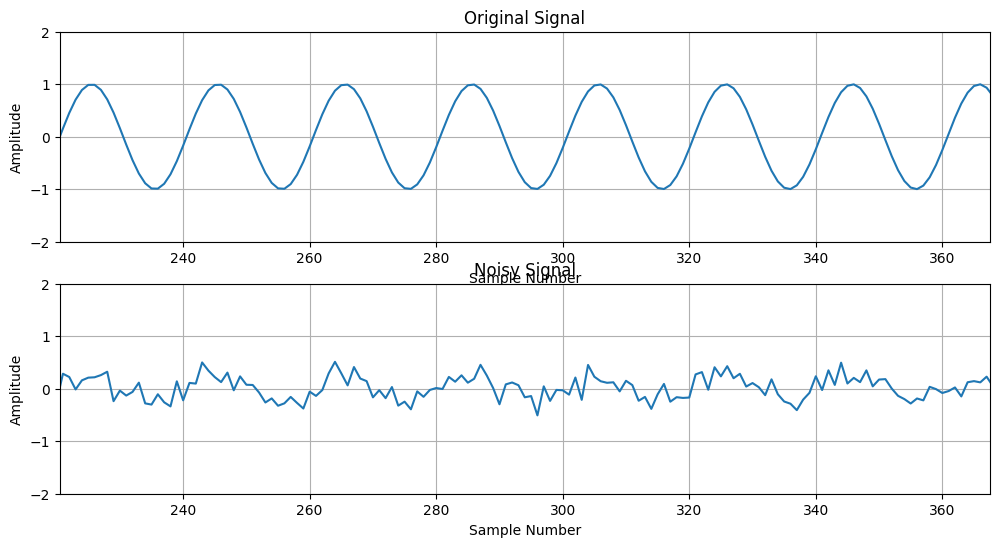

In [662]:
# Use matplotlib to visualize the signal
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(x, y)
plt.title("Original Signal")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")

min_symbol = 1.5
max_symbol = 2.5

plt.xlim(min_symbol * SYMBOL_DURATION, max_symbol * SYMBOL_DURATION)
plt.ylim(-2, 2)
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(x, noisy_y)
plt.title("Noisy Signal")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")

plt.xlim(min_symbol * SYMBOL_DURATION, max_symbol * SYMBOL_DURATION)
plt.ylim(-2, 2)
plt.grid()
plt.show()

97th Percentile of Goertzel Result: 0.23


Text(0.5, 1.0, 'Goertzel Result')

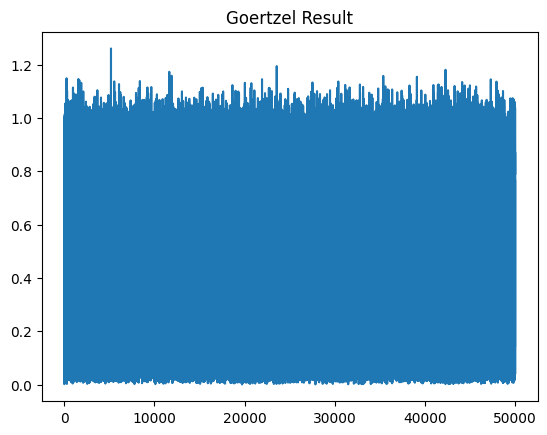

In [663]:
y = noisy_y
# ANALYSIS_FREQ = 1000
# BLOCK_SIZE = SAMPLE_RATE // ANALYSIS_FREQ
BLOCK_SIZE = SYMBOL_DURATION//1
result = list()
for i in range(0, len(x), BLOCK_SIZE):
    block = np.array(y[i:i+BLOCK_SIZE])
    res = fg.goertzel(block, MAIN_FREQ/SAMPLE_RATE)
    result.append(res[0])

# #Normalize the result to be between 0 and 1
# result = result / np.max(result)
# Get the top 97%
threshold = np.percentile(result, 97)
print(f"97th Percentile of Goertzel Result: {threshold:.2f}")
result = result/threshold

# Use matplotlib to visualize the result
plt.plot(result)
plt.title("Goertzel Result")

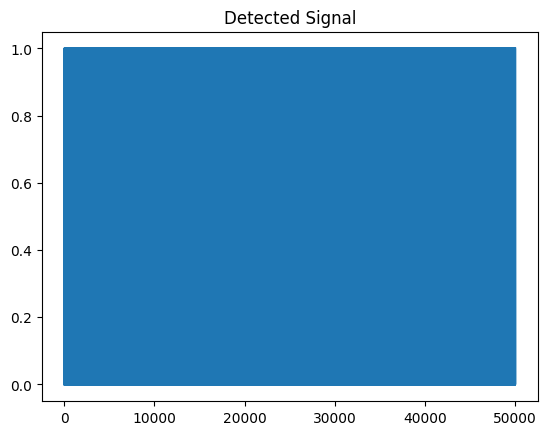

In [ ]:
# # Do a Schmitt trigger to detect the presence of the tone => Not actually useful, as we do an average later
# def schmitt_trigger(value, threshold_high, threshold_low, last_state_holder):
#     if value > threshold_high:
#         last_state_holder[0] = 1
#         return 1
#     elif value < threshold_low:
#         last_state_holder[0] = 0
#         return 0
#     else:
#         return last_state_holder[0]
# THRESHOLD_HIGH = 0.5
# THRESHOLD_LOW = 0.5
# last_state_holder = [0]
detected = [1 if r > 0.5 else 0 for r in result]
# Display the detected signal
plt.plot(detected)
plt.title("Detected Signal")
plt.show()

DETECTS_PER_STATE = len(result) // len(data)
decoded = [True if sum(detected[i:i+DETECTS_PER_STATE]) > (DETECTS_PER_STATE // 2) else False for i in range(0, len(detected), DETECTS_PER_STATE)]

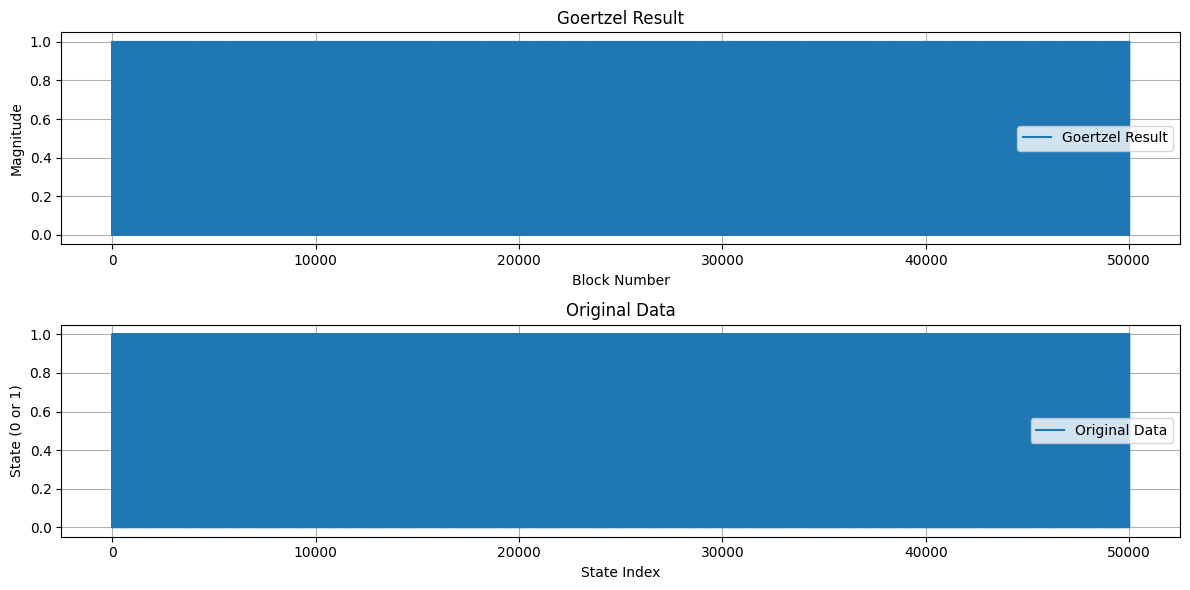

In [665]:
# Display the detected signal alongside the original data
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(decoded, label="Goertzel Result", drawstyle='steps-post')
plt.title("Goertzel Result")
plt.xlabel("Block Number")
plt.ylabel("Magnitude")
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(data, label="Original Data", drawstyle='steps-post')
plt.title("Original Data")
plt.xlabel("State Index")
plt.ylabel("State (0 or 1)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


In [666]:
# Compute the bit error rate
bit_errors = sum(d != o for d, o in zip(decoded, data))
bit_error_rate = bit_errors / len(data)
print(f"Bit error rate: {bit_error_rate:.2%} ({bit_errors} errors out of {len(data)} bits)")

Bit error rate: 0.00% (0 errors out of 50000 bits)
